In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("Datasets/home_prices.csv")
data.head()

,area_sqr_ft,bedrooms,color,price_lakhs
0,3774,2,Red,216
1,1460,3,Gray,88
2,1894,4,Gray,147
3,1730,2,Blue,84
4,1695,1,Blue,77


In [3]:
#pip install statsmodels

In [4]:
data = pd.get_dummies(data, 'color', dtype='int')
data.head()

,area_sqr_ft,bedrooms,price_lakhs,color_Blue,color_Gray,color_Green,color_Red,color_White,color_Yellow
0,3774,2,216,0,0,0,1,0,0
1,1460,3,88,0,1,0,0,0,0
2,1894,4,147,0,1,0,0,0,0
3,1730,2,84,1,0,0,0,0,0
4,1695,1,77,1,0,0,0,0,0


In [5]:
data.corr()

,area_sqr_ft,bedrooms,price_lakhs,color_Blue,color_Gray,color_Green,color_Red,color_White,color_Yellow
area_sqr_ft,1.000000,0.185810,0.945365,0.022498,-0.068944,-0.032012,0.059055,0.063827,-0.037819
bedrooms,0.185810,1.000000,0.439445,0.079767,0.040882,-0.120207,-0.004177,-0.023676,0.015286
price_lakhs,0.945365,0.439445,1.000000,0.034567,-0.040565,-0.041959,0.045803,0.051122,-0.046673
color_Blue,0.022498,0.079767,0.034567,1.000000,-0.239131,-0.196818,-0.212039,-0.189036,-0.199384
color_Gray,-0.068944,0.040882,-0.040565,-0.239131,1.000000,-0.214409,-0.230990,-0.205931,-0.217205
color_Green,-0.032012,-0.120207,-0.041959,-0.196818,-0.214409,1.000000,-0.190117,-0.169493,-0.178771
color_Red,0.059055,-0.004177,0.045803,-0.212039,-0.230990,-0.190117,1.000000,-0.182600,-0.192596
color_White,0.063827,-0.023676,0.051122,-0.189036,-0.205931,-0.169493,-0.182600,1.000000,-0.171703
color_Yellow,-0.037819,0.015286,-0.046673,-0.199384,-0.217205,-0.178771,-0.192596,-0.171703,1.000000


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

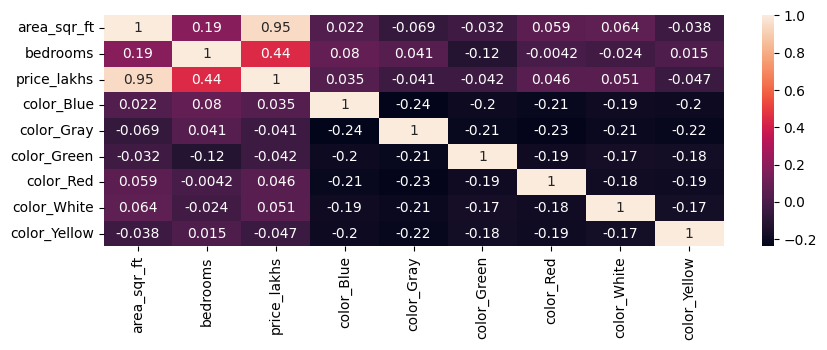

In [7]:
plt.figure(figsize = (10,3))
sns.heatmap(data.corr(), annot = True)

##### As correlation for all color values is below 0.3, we will ignore those columns

## VIF

In [8]:
df = pd.read_csv("Datasets/salaries for VIF.csv")
df.head()

,Years of Experience,Education Level,Age,Location Factor,Salary
0,29,1,49,7,124204
1,27,3,45,4,125948
2,20,4,41,8,116078
3,14,4,37,5,106486
4,20,3,42,7,113297


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Years of Experience  1000 non-null   int64
 1   Education Level      1000 non-null   int64
 2   Age                  1000 non-null   int64
 3   Location Factor      1000 non-null   int64
 4   Salary               1000 non-null   int64
dtypes: int64(5)
memory usage: 39.2 KB


In [10]:
df.corr()

,Years of Experience,Education Level,Age,Location Factor,Salary
Years of Experience,1.000000,-0.007351,0.981727,0.011790,0.928056
Education Level,-0.007351,1.000000,-0.016079,-0.023100,0.233571
Age,0.981727,-0.016079,1.000000,-0.000518,0.904480
Location Factor,0.011790,-0.023100,-0.000518,1.000000,0.192238
Salary,0.928056,0.233571,0.904480,0.192238,1.000000


<Axes: >

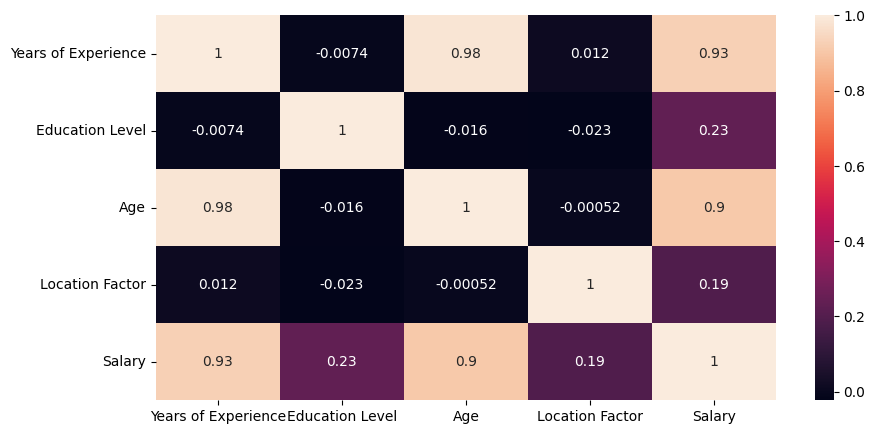

In [11]:
plt.figure(figsize = (10,5))
sns.heatmap(df.corr(), annot = True)

In [12]:
X = df.drop(["Salary"], axis = 1)

In [13]:
X

,Years of Experience,Education Level,Age,Location Factor
0,29,1,49,7
1,27,3,45,4
2,20,4,41,8
3,14,4,37,5
4,20,3,42,7
...,...,...,...,...
995,12,2,32,10
996,16,2,35,10
997,13,3,33,8
998,19,2,40,2


In [14]:
y = df['Salary']

In [15]:
y

0      124204
1      125948
2      116078
3      106486
4      113297
        ...  
995    103056
996    107691
997    100478
998    100085
999    103222
Name: Salary, Length: 1000, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
model = LinearRegression()

In [20]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
model.coef_

array([2112.13150942, 5077.27932044, -123.90813565, 1487.2251101 ])

In [22]:
df1 = df.drop('Salary', axis = 1)
df1.head()

,Years of Experience,Education Level,Age,Location Factor
0,29,1,49,7
1,27,3,45,4
2,20,4,41,8
3,14,4,37,5
4,20,3,42,7


In [23]:
df1.shape

(1000, 4)

In [24]:
df1.shape[1]

4

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [26]:
def calculateVIF(data1):
    result = pd.DataFrame()
    result['input variables'] = df1.columns
    vif = []
    for i in range(df1.shape[1]):
        vif.append(variance_inflation_factor(df1, i))
    result['VIF values'] = vif
    return result

In [27]:
calculateVIF(df1)

,input variables,VIF values
0,Years of Experience,22.342087
1,Education Level,5.472969
2,Age,42.201149
3,Location Factor,4.289467


In [28]:
df1 = df1.drop('Age', axis = 1)

In [29]:
calculateVIF(df1)

,input variables,VIF values
0,Years of Experience,3.198601
1,Education Level,3.509425
2,Location Factor,3.231181


In [30]:
data = pd.read_csv("Datasets/home_prices.csv")
data.head()

,area_sqr_ft,bedrooms,color,price_lakhs
0,3774,2,Red,216
1,1460,3,Gray,88
2,1894,4,Gray,147
3,1730,2,Blue,84
4,1695,1,Blue,77


In [35]:
data.drop('color', axis = 1, inplace=True)

In [36]:
data.describe()

,area_sqr_ft,bedrooms,price_lakhs
count,300.000000,300.000000,300.000000
mean,2371.990000,3.013333,148.050000
std,942.766953,1.446882,52.873113
min,601.000000,1.000000,15.000000
25%,1620.750000,2.000000,107.750000
50%,2342.500000,3.000000,151.000000
75%,3206.000000,4.000000,191.000000
max,3997.000000,5.000000,250.000000


In [37]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [38]:
ms = MinMaxScaler()

In [39]:
X = data.drop('price_lakhs', axis = 1)

In [40]:
X.head()

,area_sqr_ft,bedrooms
0,3774,2
1,1460,3
2,1894,4
3,1730,2
4,1695,1


In [41]:
ms_X = ms.fit_transform(X)

In [42]:
ms_df = pd.DataFrame(ms_X)
ms_df.head()

,0,1
0,0.934335,0.25
1,0.252945,0.50
2,0.380742,0.75
3,0.332450,0.25
4,0.322144,0.00


In [43]:
ms_df.describe()

,0,1
count,300.000000,300.000000
mean,0.521493,0.503333
std,0.277611,0.361720
min,0.000000,0.000000
25%,0.300280,0.250000
50%,0.512809,0.500000
75%,0.767079,0.750000
max,1.000000,1.000000


### Here we get min = 0 , therefore we do not go with MinMaxScaler(Normalization) , we use Standardization

In [44]:
sd = StandardScaler()

In [45]:
sd_X = sd.fit_transform(X)

In [46]:
sd_df = pd.DataFrame(sd_X)

In [47]:
sd_df.describe()

,0,1
count,3.000000e+02,3.000000e+02
mean,2.279658e-16,7.401487e-17
std,1.001671e+00,1.001671e+00
min,-1.881641e+00,-1.393823e+00
25%,-7.981773e-01,-7.015268e-01
50%,-3.133253e-02,-9.230616e-03
75%,8.861188e-01,6.830656e-01
max,1.726540e+00,1.375362e+00


In [48]:
from sklearn.model_selection import train_test_split

In [49]:
y = data['price_lakhs']